# Manager-community audit

This notebook audits the quarterly weighted Louvain communities produced by `scripts/10_detect_manager_communities.py`.

It checks:

1. completeness and uniqueness of manager-community assignments;
2. agreement with the ownership nodes and similarity edges;
3. reconciliation of the saved community summaries; and
4. the size and concentration of the quarterly partitions.

The notebook reads saved outputs only and does not rerun community detection. Community identifiers are quarter-specific labels and are not tracked across time.

## 1. Setup and inputs

In [1]:
import sys
from pathlib import Path

import duckdb
import pandas as pd
import pyarrow.parquet as pq


project_root = Path.cwd().resolve()

while not (project_root / "config" / "paths.yaml").is_file():
    if project_root.parent == project_root:
        raise FileNotFoundError("Could not locate the project root.")
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.utils.configuration import get_paths_config


paths = get_paths_config()
network_directory = paths.interim / "networks"
manager_path = network_directory / "ownership" / "manager_nodes.parquet"
edges_path = (
    network_directory / "manager_similarity" / "manager_similarity_edges.parquet"
)
community_directory = network_directory / "manager_communities"
assignments_path = community_directory / "manager_communities.parquet"
summary_path = community_directory / "manager_community_summary.parquet"

table_paths = {
    "manager_nodes": manager_path,
    "manager_similarity_edges": edges_path,
    "manager_communities": assignments_path,
    "manager_community_summary": summary_path,
}

for name, path in table_paths.items():
    if not path.is_file():
        raise FileNotFoundError(f"Required {name} file not found: {path}")

inventory = pd.DataFrame(
    {
        "table": table_paths.keys(),
        "rows": [
            pq.ParquetFile(path).metadata.num_rows
            for path in table_paths.values()
        ],
    }
)

connection = duckdb.connect(database=":memory:")

for name, path in table_paths.items():
    connection.read_parquet(str(path)).create_view(name)

display(inventory.style.format({"rows": "{:,}"}))

,table,rows
0,manager_nodes,"251,386"
1,manager_similarity_edges,"5,627,437"
2,manager_communities,"251,386"
3,manager_community_summary,618


## 2. Assignment integrity

Every ownership-network manager must receive exactly one positive community label in each quarter. Saved degree and neighbor-similarity measures must also remain valid.

In [2]:
assignment_checks = connection.execute(
    '''
    SELECT
        COUNT(*) - COUNT(DISTINCT (report_period, CIK))
            AS duplicate_manager_keys,
        COUNT(*) - COUNT(DISTINCT (report_period, manager_index))
            AS duplicate_manager_indices,
        COUNT(*) FILTER (
            WHERE report_period IS NULL OR manager_index IS NULL
               OR CIK IS NULL OR community_id IS NULL
        ) AS missing_assignment_fields,
        COUNT(*) FILTER (WHERE community_id < 1)
            AS invalid_community_ids,
        COUNT(*) FILTER (
            WHERE similarity_degree < 0
               OR mean_neighbor_similarity < 0
               OR mean_neighbor_similarity > 1
        ) AS invalid_similarity_statistics
    FROM manager_communities
    '''
).fetchdf().T.reset_index()
assignment_checks.columns = ["check", "violations"]

summary_checks = connection.execute(
    '''
    SELECT
        COUNT(*) - COUNT(DISTINCT (report_period, community_id))
            AS duplicate_community_keys,
        COUNT(*) FILTER (
            WHERE manager_count <= 0 OR manager_share <= 0
               OR manager_share > 1
               OR total_reported_portfolio_value_usd <= 0
               OR median_reported_portfolio_value_usd <= 0
               OR mean_security_count <= 0
               OR mean_largest_position_weight <= 0
               OR mean_largest_position_weight > 1
               OR mean_portfolio_hhi <= 0 OR mean_portfolio_hhi > 1
               OR mean_similarity_degree < 0
        ) AS invalid_community_statistics
    FROM manager_community_summary
    '''
).fetchdf().T.reset_index()
summary_checks.columns = ["check", "violations"]

integrity_checks = pd.concat(
    [assignment_checks, summary_checks], ignore_index=True
)

display(integrity_checks.style.format({"violations": "{:,}"}))
print()
print(f"Total assignment-integrity violations: {integrity_checks['violations'].sum():,}")

,check,violations
0,duplicate_manager_keys,0
1,duplicate_manager_indices,0
2,missing_assignment_fields,0
3,invalid_community_ids,0
4,invalid_similarity_statistics,0
5,duplicate_community_keys,0
6,invalid_community_statistics,0



Total assignment-integrity violations: 0


## 3. Reconciliation with managers and edges

Assignments should preserve every manager-node field. Similarity degree and mean neighbor similarity are recalculated from the two endpoints of the undirected edge table.

In [3]:
assignment_reconciliation = connection.execute(
    '''
    WITH endpoints AS (
        SELECT
            report_period,
            manager_a_index AS manager_index,
            cosine_similarity
        FROM manager_similarity_edges
        UNION ALL
        SELECT
            report_period,
            manager_b_index AS manager_index,
            cosine_similarity
        FROM manager_similarity_edges
    ),
    edge_statistics AS (
        SELECT
            report_period,
            manager_index,
            COUNT(*) AS similarity_degree,
            AVG(cosine_similarity) AS mean_neighbor_similarity
        FROM endpoints
        GROUP BY report_period, manager_index
    )
    SELECT
        COUNT(*) FILTER (WHERE c.CIK IS NULL)
            AS nodes_without_assignments,
        COUNT(*) FILTER (WHERE n.CIK IS NULL)
            AS assignments_without_nodes,
        COUNT(*) FILTER (
            WHERE c.PERIODOFREPORT != n.PERIODOFREPORT
               OR c.information_date != n.information_date
               OR c.FILINGMANAGER_NAME != n.FILINGMANAGER_NAME
               OR c.portfolio_value_usd != n.portfolio_value_usd
               OR c.security_count != n.security_count
               OR c.underlying_position_rows != n.underlying_position_rows
               OR abs(c.largest_position_weight - n.largest_position_weight)
                    > 1e-12
               OR abs(c.portfolio_hhi - n.portfolio_hhi) > 1e-12
        ) AS manager_field_mismatches,
        COUNT(*) FILTER (WHERE e.manager_index IS NULL)
            AS managers_without_edges,
        COUNT(*) FILTER (
            WHERE c.similarity_degree != e.similarity_degree
               OR abs(
                    c.mean_neighbor_similarity - e.mean_neighbor_similarity
                  ) > 1e-12
        ) AS edge_statistic_mismatches
    FROM manager_communities AS c
    FULL JOIN manager_nodes AS n
        USING (report_period, manager_index, CIK)
    LEFT JOIN edge_statistics AS e
        ON c.report_period = e.report_period
       AND c.manager_index = e.manager_index
    '''
).fetchdf().T.reset_index()
assignment_reconciliation.columns = ["check", "violations"]

display(assignment_reconciliation.style.format({"violations": "{:,}"}))
print()
print(
    "Total assignment-reconciliation violations: "
    f"{assignment_reconciliation['violations'].sum():,}"
)

,check,violations
0,nodes_without_assignments,0
1,assignments_without_nodes,0
2,manager_field_mismatches,0
3,managers_without_edges,0
4,edge_statistic_mismatches,0



Total assignment-reconciliation violations: 0


## 4. Community-summary reconciliation

Community statistics are independently aggregated from the manager assignments. Community shares should sum to one, and community labels should be consecutive within every quarter.

In [4]:
summary_reconciliation = connection.execute(
    '''
    WITH calculated AS (
        SELECT
            report_period,
            community_id,
            COUNT(*) AS manager_count,
            COUNT(*)::DOUBLE
                / SUM(COUNT(*)) OVER (PARTITION BY report_period)
                AS manager_share,
            SUM(portfolio_value_usd)
                AS total_reported_portfolio_value_usd,
            MEDIAN(portfolio_value_usd)
                AS median_reported_portfolio_value_usd,
            AVG(security_count) AS mean_security_count,
            AVG(largest_position_weight) AS mean_largest_position_weight,
            AVG(portfolio_hhi) AS mean_portfolio_hhi,
            AVG(similarity_degree) AS mean_similarity_degree
        FROM manager_communities
        GROUP BY report_period, community_id
    ),
    comparison AS (
        SELECT
            s.report_period AS saved_period,
            c.report_period AS calculated_period,
            s.*,
            c.manager_count AS calculated_count,
            c.manager_share AS calculated_share,
            c.total_reported_portfolio_value_usd AS calculated_value,
            c.median_reported_portfolio_value_usd AS calculated_median_value,
            c.mean_security_count AS calculated_security_count,
            c.mean_largest_position_weight AS calculated_largest_weight,
            c.mean_portfolio_hhi AS calculated_hhi,
            c.mean_similarity_degree AS calculated_degree
        FROM manager_community_summary AS s
        FULL JOIN calculated AS c USING (report_period, community_id)
    )
    SELECT
        COUNT(*) FILTER (WHERE calculated_period IS NULL)
            AS summaries_without_assignments,
        COUNT(*) FILTER (WHERE saved_period IS NULL)
            AS assignments_without_summaries,
        COUNT(*) FILTER (
            WHERE manager_count != calculated_count
               OR total_reported_portfolio_value_usd != calculated_value
               OR abs(manager_share - calculated_share) > 1e-12
               OR abs(
                    median_reported_portfolio_value_usd
                    - calculated_median_value
                  ) > 1e-8
               OR abs(mean_security_count - calculated_security_count) > 1e-12
               OR abs(
                    mean_largest_position_weight - calculated_largest_weight
                  ) > 1e-12
               OR abs(mean_portfolio_hhi - calculated_hhi) > 1e-12
               OR abs(mean_similarity_degree - calculated_degree) > 1e-12
        ) AS community_statistic_mismatches
    FROM comparison
    '''
).fetchdf().T.reset_index()
summary_reconciliation.columns = ["check", "violations"]

community_summary = connection.execute(
    '''
    SELECT report_period, community_id, manager_count, manager_share
    FROM manager_community_summary
    ORDER BY report_period, community_id
    '''
).fetchdf()

quarter_checks = pd.DataFrame(
    {
        "check": [
            "Quarters whose community shares do not sum to one",
            "Quarters with nonconsecutive community labels",
            "Quarters not ordered by decreasing community size",
        ],
        "violations": [
            community_summary.groupby("report_period")["manager_share"]
                .sum().sub(1).abs().gt(1e-12).sum(),
            community_summary.groupby("report_period")["community_id"]
                .apply(
                    lambda values: list(values)
                    != list(range(1, len(values) + 1))
                ).sum(),
            community_summary.groupby("report_period")["manager_count"]
                .apply(lambda values: not values.is_monotonic_decreasing).sum(),
        ],
    }
)

display(summary_reconciliation.style.format({"violations": "{:,}"}))
display(quarter_checks.style.format({"violations": "{:,}"}))

,check,violations
0,summaries_without_assignments,0
1,assignments_without_summaries,0
2,community_statistic_mismatches,0


,check,violations
0,Quarters whose community shares do not sum to one,0
1,Quarters with nonconsecutive community labels,0
2,Quarters not ordered by decreasing community size,0


## 5. Community structure

Community counts and sizes show the granularity and concentration of each quarterly partition.

In [5]:
quarterly_communities = connection.execute(
    '''
    SELECT
        report_period,
        COUNT(*) AS communities,
        MAX(manager_count) AS largest_community,
        MAX(manager_share) AS largest_community_share,
        MEDIAN(manager_count) AS median_community_size
    FROM manager_community_summary
    GROUP BY report_period
    ORDER BY report_period
    '''
).fetchdf()

community_structure = (
    quarterly_communities[
        ["communities", "largest_community_share", "median_community_size"]
    ]
    .agg(["min", "median", "max"])
    .T.reset_index(names="measure")
)
display(community_structure.style.format({
    "min": "{:.3f}", "median": "{:.3f}", "max": "{:.3f}"
}))
print()
print("First and last quarterly partitions")
display(pd.concat([quarterly_communities.head(1), quarterly_communities.tail(1)]))

connection.close()

,measure,min,median,max
0,communities,7.000,11.500,18.000
1,largest_community_share,0.171,0.221,0.450
2,median_community_size,117.000,254.500,599.000



First and last quarterly partitions


,report_period,communities,largest_community,largest_community_share,median_community_size
0,2013-06-30,7,1204,0.450262,150.0
51,2026-03-31,13,1382,0.176659,386.0


### Community evolution: Matplotlib

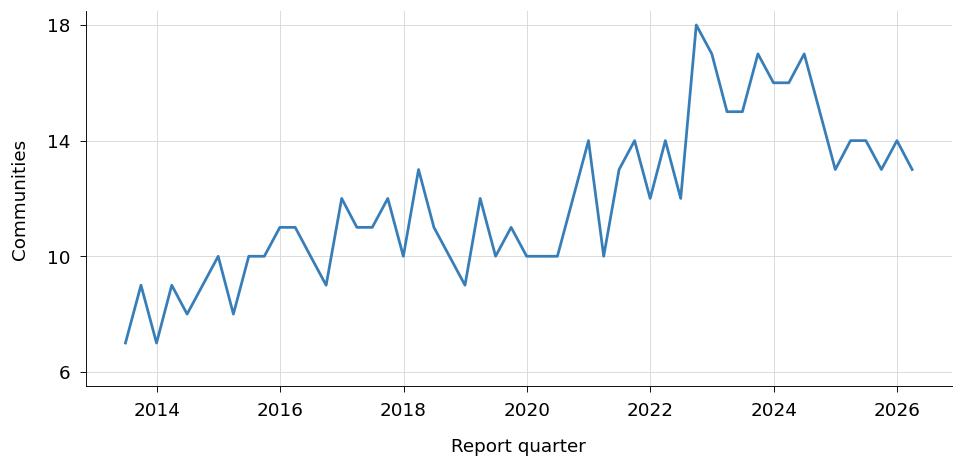

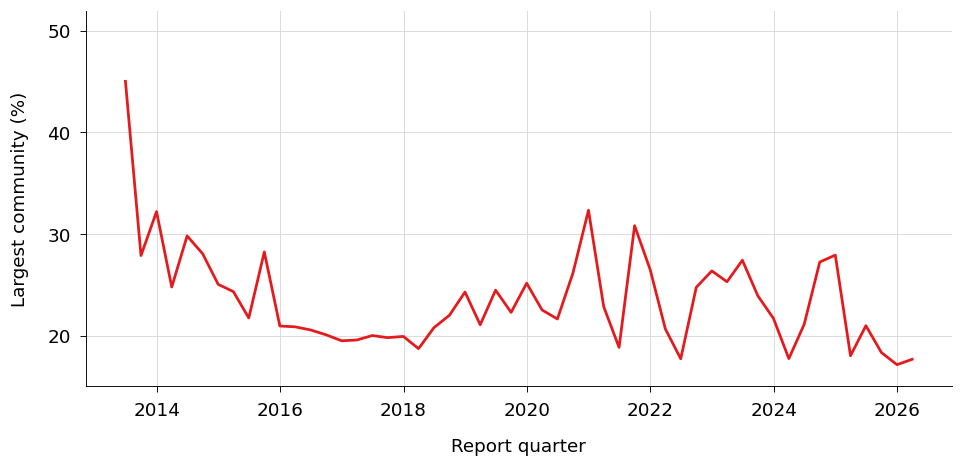

In [6]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
from matplotlib.ticker import PercentFormatter

from src.visualization.style import (
    COLOR_PALETTE,
    SINGLE_PANEL_SIZE,
    apply_matplotlib_layout,
    set_matplotlib_style,
)


set_matplotlib_style()
count_figure, count_axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)

count_axis.plot(quarterly_communities["report_period"], quarterly_communities["communities"])
count_axis.set_ylabel("Communities")
count_axis.set_xlabel("Report quarter")
count_axis.yaxis.set_major_locator(MaxNLocator(integer=True))
count_axis.set_yticks(np.arange(6, 21, 4))
count_axis.set_ylim(5.5, 18.5)

apply_matplotlib_layout(count_figure)
count_figure.savefig(paths.figures / "02_02_community_count_matplotlib.pdf")

share_figure, share_axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
share_axis.plot(
    quarterly_communities["report_period"],
    100 * quarterly_communities["largest_community_share"],
    color=COLOR_PALETTE[1],
)
share_axis.set_yticks(np.arange(20, 51, 10))
share_axis.set_ylim(15, 52)
share_axis.set_ylabel("Largest community (%)")
share_axis.set_xlabel("Report quarter")

apply_matplotlib_layout(share_figure)
share_figure.savefig(paths.figures / "02_02_largest_community_share_matplotlib.pdf")
plt.show()

## 6. Interpretation

- **Every manager receives one valid assignment.** The community table contains the same 251,386 manager-quarter observations as the ownership manager-node table, with no duplicate, missing, or invalid assignments.
- **Assignments reproduce the similarity graph.** Saved manager attributes, similarity degrees, and mean neighbor similarities agree exactly with the ownership nodes and the 5,627,437 similarity edges.
- **Community summaries reconcile exactly.** All 618 quarter-community rows reproduce from the manager assignments. Community shares sum to one, identifiers are consecutive, and labels are ordered by decreasing community size within every quarter.
- **Partition granularity changes over time.** Quarterly partitions contain 7 to 18 communities, with a median of 11.5. The largest community contains between 17.1% and 45.0% of managers; its share falls from 45.0% in the first quarter to 17.7% in the last quarter.

The saved quarterly communities are complete and internally consistent, so they are suitable for constructing stock-level community features. Community identifiers remain descriptive quarter-specific labels and must not be interpreted as stable identities across time.